# End-to-End Marketing Mix Model Project (Using marketing.csv) - Refined

This notebook performs a Marketing Mix Model (MMM) analysis using the provided `marketing.csv` dataset. This version includes refinements to address multicollinearity identified in previous runs.

**Objective:** To build a more stable and interpretable MMM to understand the impact of various marketing levers and external factors on weekly Gross Merchandise Value (GMV), calculate ROI/elasticity, and provide insights for budget optimization.

**Steps:**
1. Load Data from CSV.
2. Data Cleaning & Preparation.
3. Perform Feature Engineering (Adstock, Moving Averages, Lags).
4. Exploratory Data Analysis (EDA).
5. Build and Evaluate Multiple Model Types (Linear, Multiplicative, Koyck, Distributed Lag) with refined feature selection and VIF handling.
6. Calculate and Interpret Elasticities for the final chosen model.

In [1]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import KFold, cross_val_score
import os # To handle file path

# Set display options
pd.set_option('display.float_format', '{:0.3f}'.format)
pd.set_option('display.max_row', 200)
pd.set_option('display.max_columns', 100)

## 1. Load Data from CSV

In [2]:
# --- Load Data ---
csv_filename = 'marketing.csv'
if os.path.exists(csv_filename):
    model_data = pd.read_csv(csv_filename)
    print(f"Successfully loaded data from {csv_filename}")
    print("Data shape:", model_data.shape)
    print("\nData Info:")
    model_data.info()
    print("\nData Head:")
    print(model_data.head())
else:
    print(f"Error: {csv_filename} not found. Please ensure the file is uploaded correctly.")
    model_data = None

Successfully loaded data from marketing.csv
Data shape: (104, 23)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   week                     104 non-null    int64  
 1   Date                     104 non-null    object 
 2   gmv                      104 non-null    float64
 3   listing_price            104 non-null    float64
 4   product_mrp              104 non-null    float64
 5   discount                 104 non-null    float64
 6   sla                      104 non-null    float64
 7   product_procurement_sla  104 non-null    float64
 8   online_order_perc        104 non-null    float64
 9   Total_Investment         104 non-null    float64
 10  TV                       104 non-null    float64
 11  Digital                  104 non-null    float64
 12  Sponsorship              104 non-null    float64
 13  Co

## 2. Data Cleaning & Preparation

In [3]:
if model_data is not None:
    # Convert Date column to datetime objects
    model_data['Date'] = pd.to_datetime(model_data['Date'])

    # Check for missing values
    print("\nMissing values per column:")
    print(model_data.isnull().sum())

    # Check basic statistics
    print("\nBasic Statistics:")
    print(model_data.describe())
else:
    print("Skipping Data Preparation as data loading failed.")


Missing values per column:
week                       0
Date                       0
gmv                        0
listing_price              0
product_mrp                0
discount                   0
sla                        0
product_procurement_sla    0
online_order_perc          0
Total_Investment           0
TV                         0
Digital                    0
Sponsorship                0
Content_marketing          0
Online_marketing           0
Affiliates                 0
SEM                        0
Radio                      0
Other                      0
NPS                        0
Stock_Index                0
Special_sales              0
Payday                     0
dtype: int64

Basic Statistics:
         week                 Date        gmv  listing_price  product_mrp  \
count 104.000                  104    104.000        104.000      104.000   
mean   52.500  2022-12-29 12:00:00 178575.988       1293.647     1532.690   
min     1.000  2022-01-03 00:00:00 111315.

## 3. Feature Engineering

In [4]:
if model_data is not None:
    # --- Adstock Calculation ---
    def adstocked_advertising(series, adstock_rate=0.5):
        """Calculates adstock for a given marketing spend series."""
        adstocked_series = []
        for i in range(len(series)):
            if i == 0:
                adstocked_series.append(series.iloc[i])
            else:
                adstocked_series.append(series.iloc[i] + adstock_rate * adstocked_series[i-1])
        return pd.Series(adstocked_series, index=series.index)

    adstock_rate = 0.5 # Can be tuned
    marketing_cols = ['TV', 'Digital', 'Sponsorship', 'Content_marketing',
                      'Online_marketing', 'Affiliates', 'SEM', 'Radio', 'Other']

    print("\nCalculating Adstock...")
    for col in marketing_cols:
        if col in model_data.columns:
             model_data[f'{col}_ads'] = adstocked_advertising(model_data[col], adstock_rate)
        else:
             print(f"Warning: Marketing column '{col}' not found.")

    # --- Moving Averages and Inflation/Difference ---
    # Refined: Calculate fewer MA terms initially to reduce multicollinearity
    print("\nCalculating Moving Averages and Inflation (Refined)...")
    price_col = 'listing_price'
    discount_col = 'discount'

    if price_col in model_data.columns and discount_col in model_data.columns:
        # Use only a longer window (e.g., 4 weeks) for MA inflation
        window = 4
        model_data[f'MA{window}_LP'] = model_data[price_col].rolling(window=window, min_periods=1).mean()
        model_data[f'MA{window}_Discount'] = model_data[discount_col].rolling(window=window, min_periods=1).mean()
        model_data[f'MA{window}_list_price_inf'] = (model_data[price_col] - model_data[f'MA{window}_LP']) / model_data[f'MA{window}_LP'].replace(0, np.nan)
        model_data[f'MA{window}_discount_inf'] = (model_data[discount_col] - model_data[f'MA{window}_Discount']) / model_data[f'MA{window}_Discount'].replace(0, np.nan)

        ma_cols = [col for col in model_data.columns if '_inf' in col]
        model_data[ma_cols] = model_data[ma_cols].fillna(0)
        ma_cols_to_drop = [f'MA{window}_LP', f'MA{window}_Discount']
        model_data.drop(columns=ma_cols_to_drop, inplace=True, errors='ignore')
    else:
        print("Warning: 'listing_price' or 'discount' not found. Skipping MA calculation.")

    # --- Lag Variables ---
    # Refined: Consider fewer lags initially or be selective
    print("\nCalculating Lag Variables (Refined)...")
    lag_vars = ['gmv', 'listing_price', 'discount', 'NPS', 'Special_sales', 'Payday'] # Exclude Stock_Index lags initially due to high VIF
    lag_vars = [var for var in lag_vars if var in model_data.columns]

    if lag_vars:
        for var in lag_vars:
            for lag in [1]: # Use only lag 1 initially
                model_data[f'lag_{lag}_{var}'] = model_data[var].shift(lag)
        lag_cols = [col for col in model_data.columns if 'lag_' in col]
        model_data[lag_cols] = model_data[lag_cols].fillna(0)
    else:
         print("Warning: No suitable columns found for lagging.")

    print("\nFeature Engineering Complete. DataFrame shape:", model_data.shape)
    print(model_data.head())
else:
    print("Skipping Feature Engineering as data loading failed.")


Calculating Adstock...

Calculating Moving Averages and Inflation (Refined)...

Calculating Lag Variables (Refined)...

Feature Engineering Complete. DataFrame shape: (104, 40)
   week       Date        gmv  listing_price  product_mrp  discount   sla  \
0     1 2022-01-03 138384.115       1342.009     1504.339     0.108 3.288   
1     2 2022-01-10 145141.010       1355.804     1529.649     0.114 5.298   
2     3 2022-01-17 131880.653       1307.114     1449.680     0.098 4.782   
3     4 2022-01-24 141377.157       1249.877     1469.802     0.150 6.174   
4     5 2022-01-31 121818.423       1337.969     1610.985     0.169 3.631   

   product_procurement_sla  online_order_perc  Total_Investment        TV  \
0                    2.375             77.849         56290.658 11880.947   
1                    1.784             61.731         59029.799 10144.739   
2                    2.318             83.244         57691.294  8914.054   
3                    1.807             80.501      

## 4. Exploratory Data Analysis (EDA)


Visualizing GMV Trend...


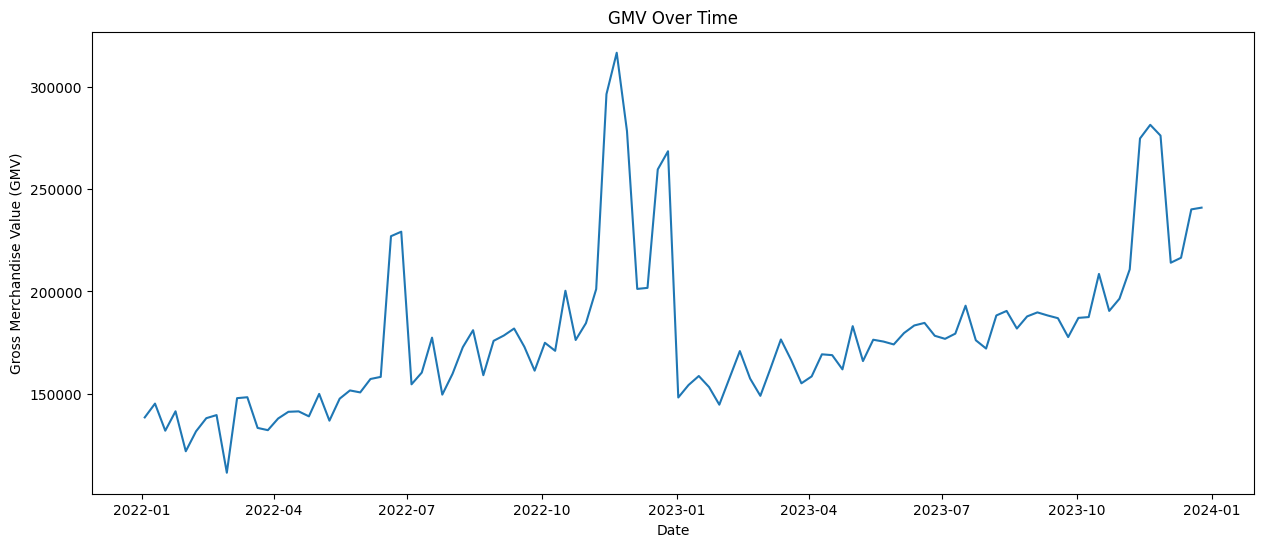


Generating Correlation Heatmap...


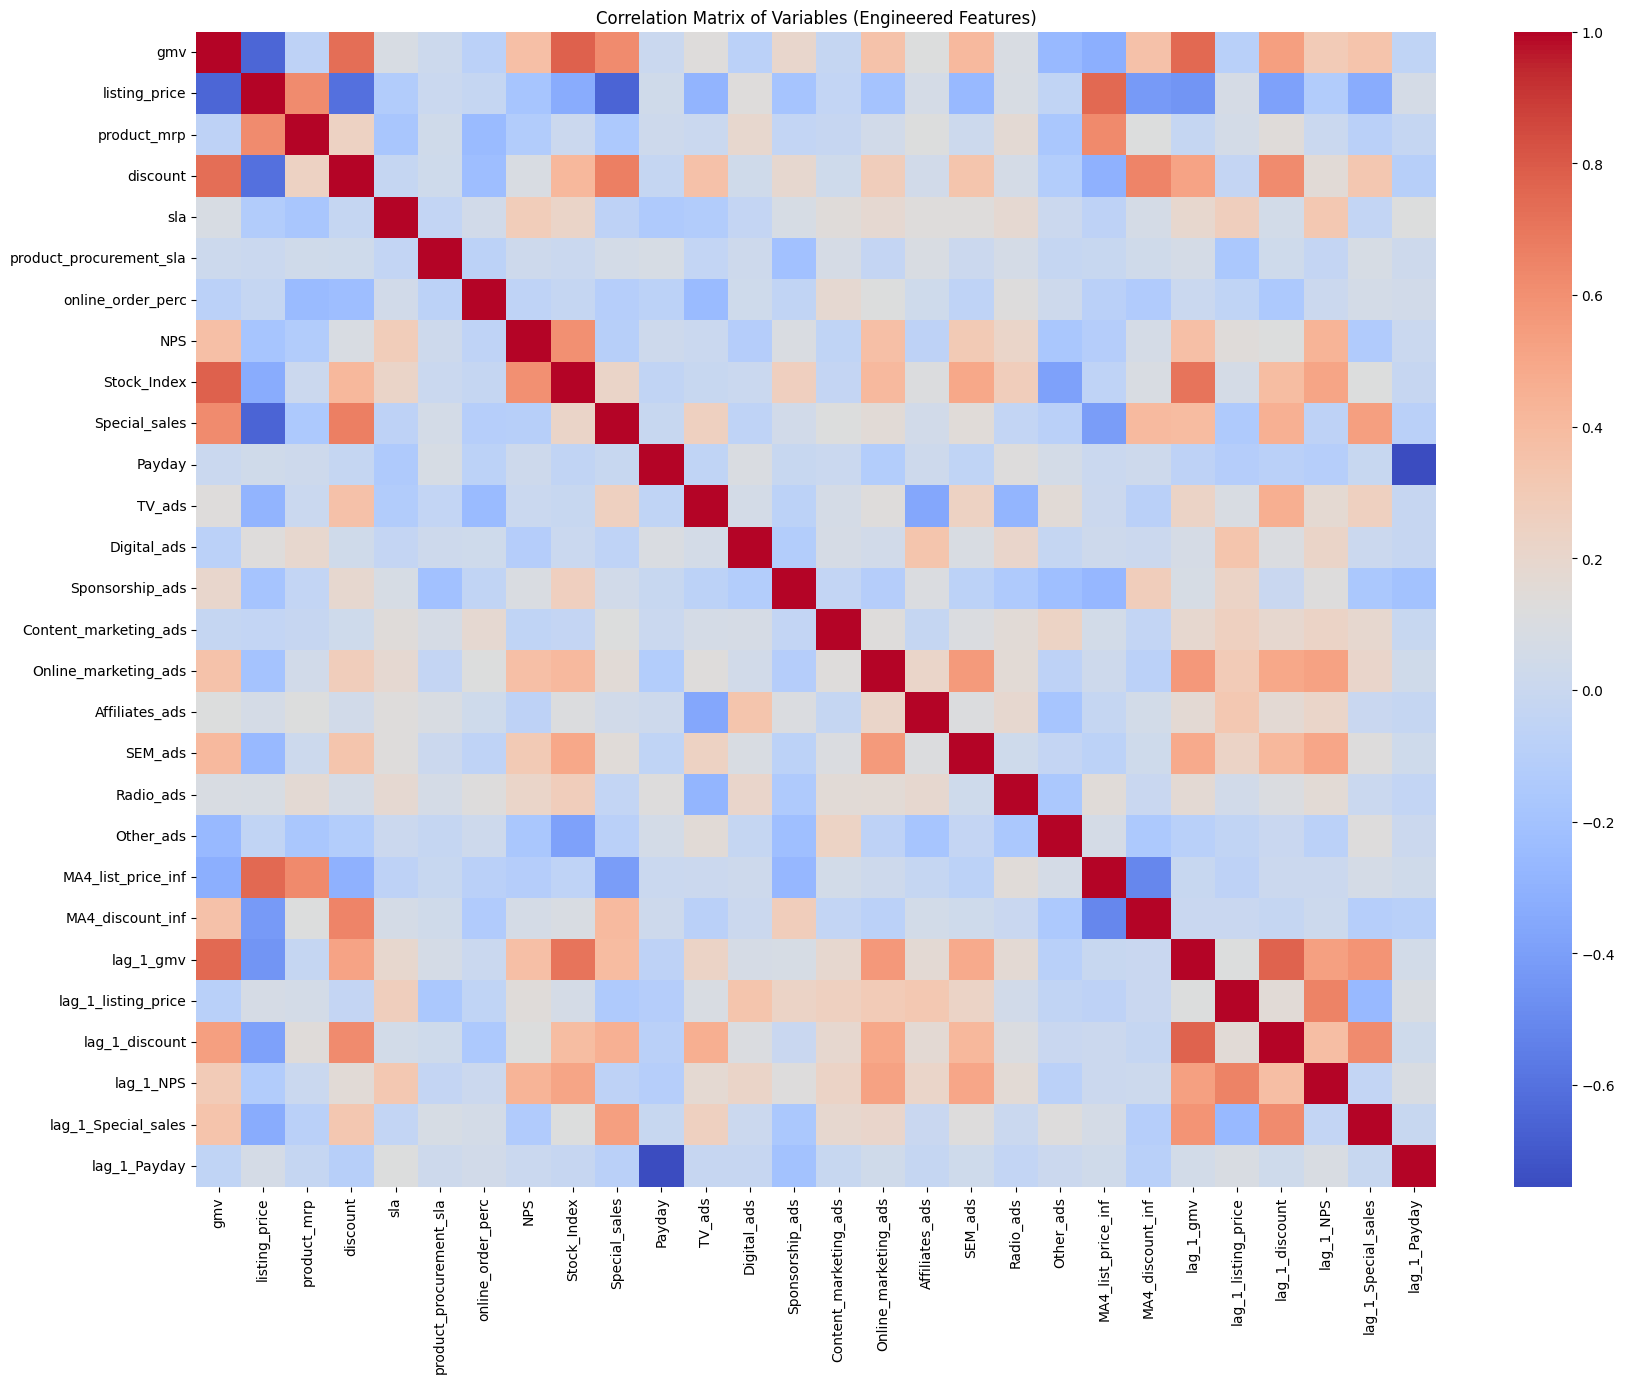


Correlation with GMV:
gmv                        1.000
Stock_Index                0.774
lag_1_gmv                  0.752
discount                   0.730
Special_sales              0.621
lag_1_discount             0.537
SEM_ads                    0.408
NPS                        0.374
MA4_discount_inf           0.358
Online_marketing_ads       0.354
lag_1_Special_sales        0.344
lag_1_NPS                  0.297
Sponsorship_ads            0.199
TV_ads                     0.132
Affiliates_ads             0.119
Radio_ads                  0.094
sla                        0.088
product_procurement_sla    0.020
Payday                     0.002
Content_marketing_ads     -0.025
lag_1_Payday              -0.051
product_mrp               -0.068
Digital_ads               -0.077
online_order_perc         -0.080
lag_1_listing_price       -0.091
Other_ads                 -0.258
MA4_list_price_inf        -0.316
listing_price             -0.646
Name: gmv, dtype: float64


In [5]:
if model_data is not None:
    # --- Visualize GMV Trend ---
    print("\nVisualizing GMV Trend...")
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=model_data, x='Date', y='gmv')
    plt.title('GMV Over Time')
    plt.xlabel('Date')
    plt.ylabel('Gross Merchandise Value (GMV)')
    plt.show()

    # --- Correlation Heatmap ---
    print("\nGenerating Correlation Heatmap...")
    plt.figure(figsize=(20, 15))
    numeric_df = model_data.select_dtypes(include=np.number)
    # Exclude highly correlated basic marketing spends if adstock versions exist
    cols_to_drop_corr = [col for col in marketing_cols if f'{col}_ads' in numeric_df.columns]
    numeric_df_corr = numeric_df.drop(columns=cols_to_drop_corr + ['week', 'Total_Investment'], errors='ignore')
    sns.heatmap(numeric_df_corr.corr(), cmap="coolwarm", annot=False)
    plt.title('Correlation Matrix of Variables (Engineered Features)')
    plt.show()

    # Display correlation with target variable 'gmv'
    print("\nCorrelation with GMV:")
    if 'gmv' in numeric_df_corr.columns:
        correlation_matrix = numeric_df_corr.corr()
        print(correlation_matrix['gmv'].sort_values(ascending=False))
    else:
        print("GMV column not found for correlation analysis.")
else:
    print("Skipping EDA as data loading failed.")

## 5. Modeling

Building models with refined feature selection and VIF handling.


--- Building Linear Model (Refined) ---
Initial features for Stepwise (Linear): 25

Refining model with 25 features...
Removing feature 'listing_price' (VIF > 5.0 and P-value > 0.05)

Refining model with 24 features...
Removing feature 'lag_1_discount' (VIF > 5.0 and P-value > 0.05)

Refining model with 23 features...
Removing feature 'MA4_discount_inf' (VIF > 5.0 and P-value > 0.05)

Refining model with 22 features...
No features with VIF > threshold. Stopping refinement.

Final selected features after VIF/P-value refinement: ['discount', 'sla', 'product_procurement_sla', 'online_order_perc', 'NPS', 'Stock_Index', 'Special_sales', 'Payday', 'TV_ads', 'Digital_ads', 'Sponsorship_ads', 'Content_marketing_ads', 'Online_marketing_ads', 'Affiliates_ads', 'SEM_ads', 'Radio_ads', 'Other_ads', 'MA4_list_price_inf', 'lag_1_listing_price', 'lag_1_NPS', 'lag_1_Special_sales', 'lag_1_Payday']

--- Final Linear Model Summary ---
                            OLS Regression Results                  

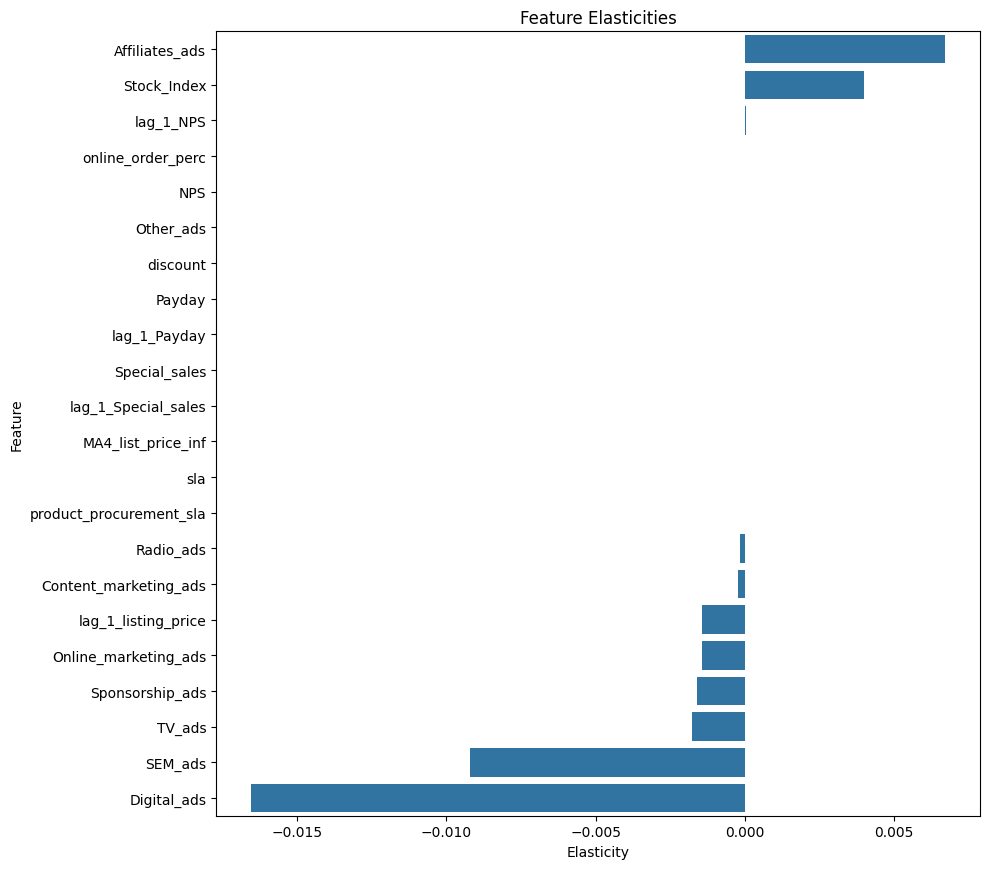

                    Feature  Elasticity
13           Affiliates_ads       0.007
5               Stock_Index       0.004
19                lag_1_NPS       0.000
3         online_order_perc       0.000
4                       NPS       0.000
16                Other_ads       0.000
0                  discount       0.000
7                    Payday       0.000
21             lag_1_Payday       0.000
6             Special_sales       0.000
20      lag_1_Special_sales       0.000
17       MA4_list_price_inf       0.000
1                       sla      -0.000
2   product_procurement_sla      -0.000
15                Radio_ads      -0.000
11    Content_marketing_ads      -0.000
18      lag_1_listing_price      -0.001
12     Online_marketing_ads      -0.001
10          Sponsorship_ads      -0.002
8                    TV_ads      -0.002
14                  SEM_ads      -0.009
9               Digital_ads      -0.017

--- Building Multiplicative Model (Log-Log) (Refined) ---
Initial features for 

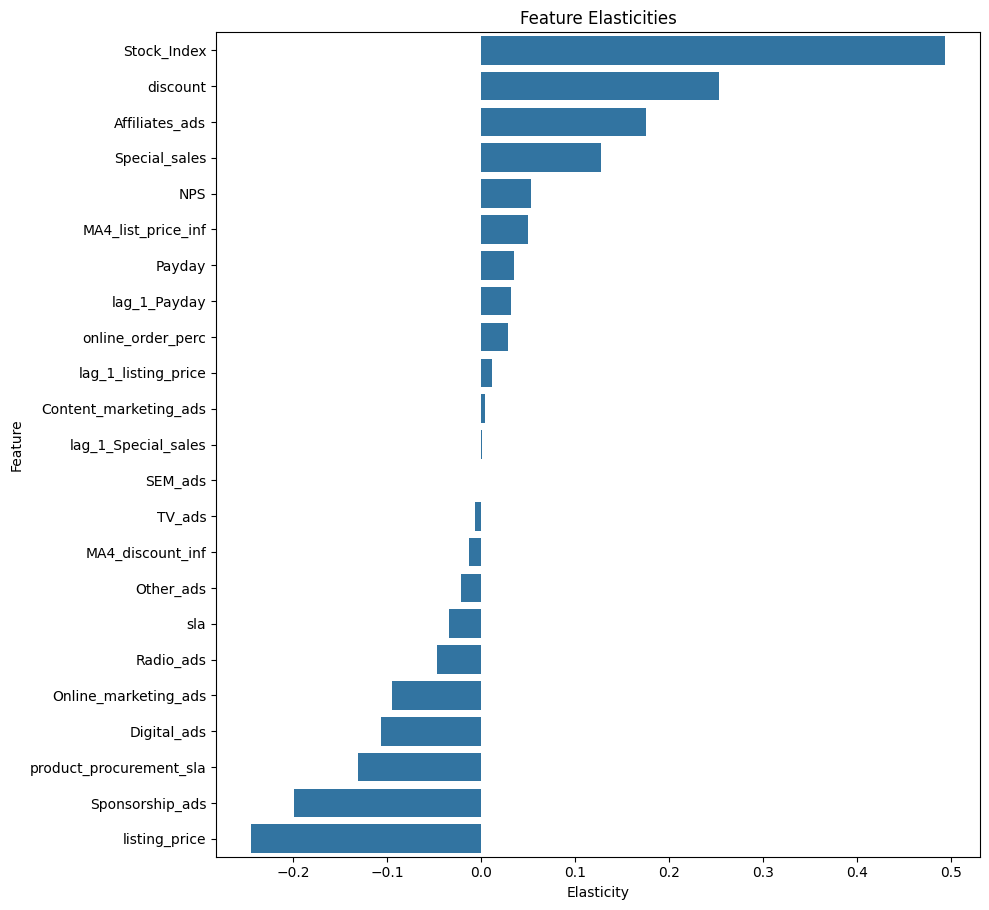

                    Feature  Elasticity
6               Stock_Index       0.494
1                  discount       0.254
14           Affiliates_ads       0.175
7             Special_sales       0.128
5                       NPS       0.054
18       MA4_list_price_inf       0.050
8                    Payday       0.036
22             lag_1_Payday       0.032
4         online_order_perc       0.029
20      lag_1_listing_price       0.011
12    Content_marketing_ads       0.005
21      lag_1_Special_sales       0.001
15                  SEM_ads       0.001
9                    TV_ads      -0.006
19         MA4_discount_inf      -0.013
17                Other_ads      -0.021
2                       sla      -0.034
16                Radio_ads      -0.047
13     Online_marketing_ads      -0.095
10              Digital_ads      -0.107
3   product_procurement_sla      -0.130
11          Sponsorship_ads      -0.199
0             listing_price      -0.245

--- Building Koyck Model (Refined) ---


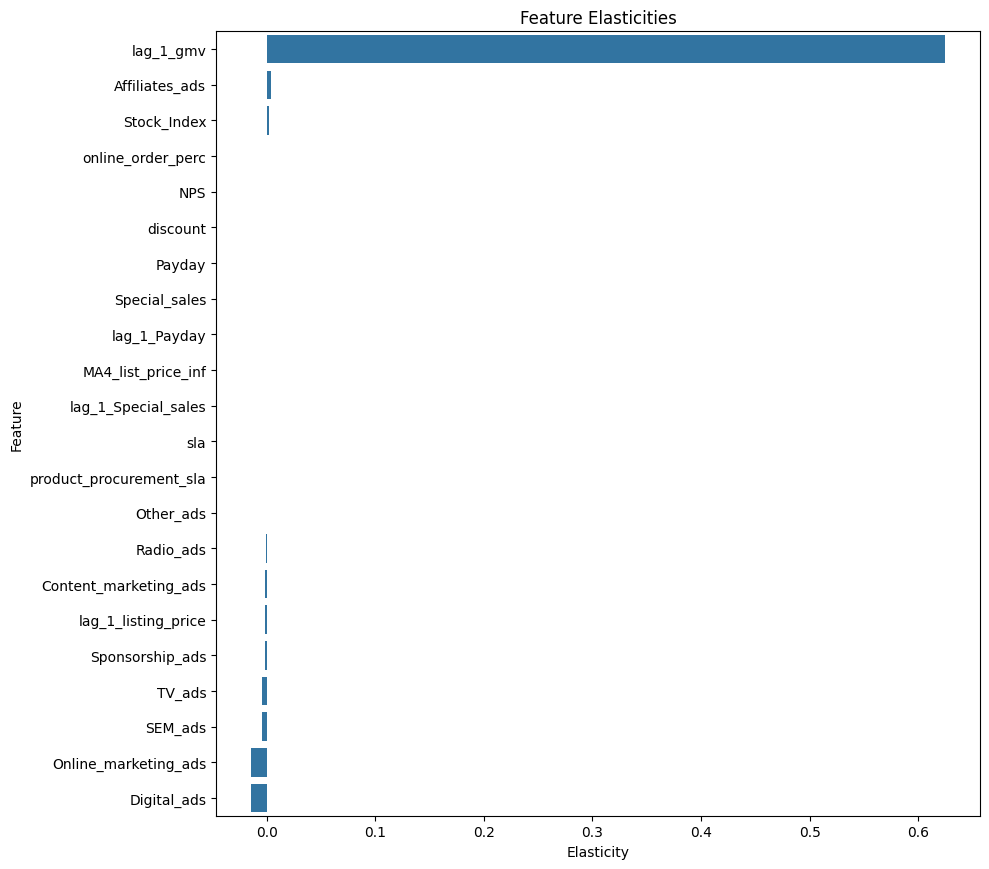

                    Feature  Elasticity
21                lag_1_gmv       0.625
13           Affiliates_ads       0.004
5               Stock_Index       0.003
3         online_order_perc       0.000
4                       NPS       0.000
0                  discount       0.000
7                    Payday       0.000
6             Special_sales       0.000
20             lag_1_Payday       0.000
17       MA4_list_price_inf       0.000
19      lag_1_Special_sales      -0.000
1                       sla      -0.000
2   product_procurement_sla      -0.000
16                Other_ads      -0.000
15                Radio_ads      -0.000
11    Content_marketing_ads      -0.001
18      lag_1_listing_price      -0.002
10          Sponsorship_ads      -0.002
8                    TV_ads      -0.004
14                  SEM_ads      -0.004
12     Online_marketing_ads      -0.014
9               Digital_ads      -0.015

--- Building Distributed Lag Model (Refined) ---
Initial features for Stepwise 

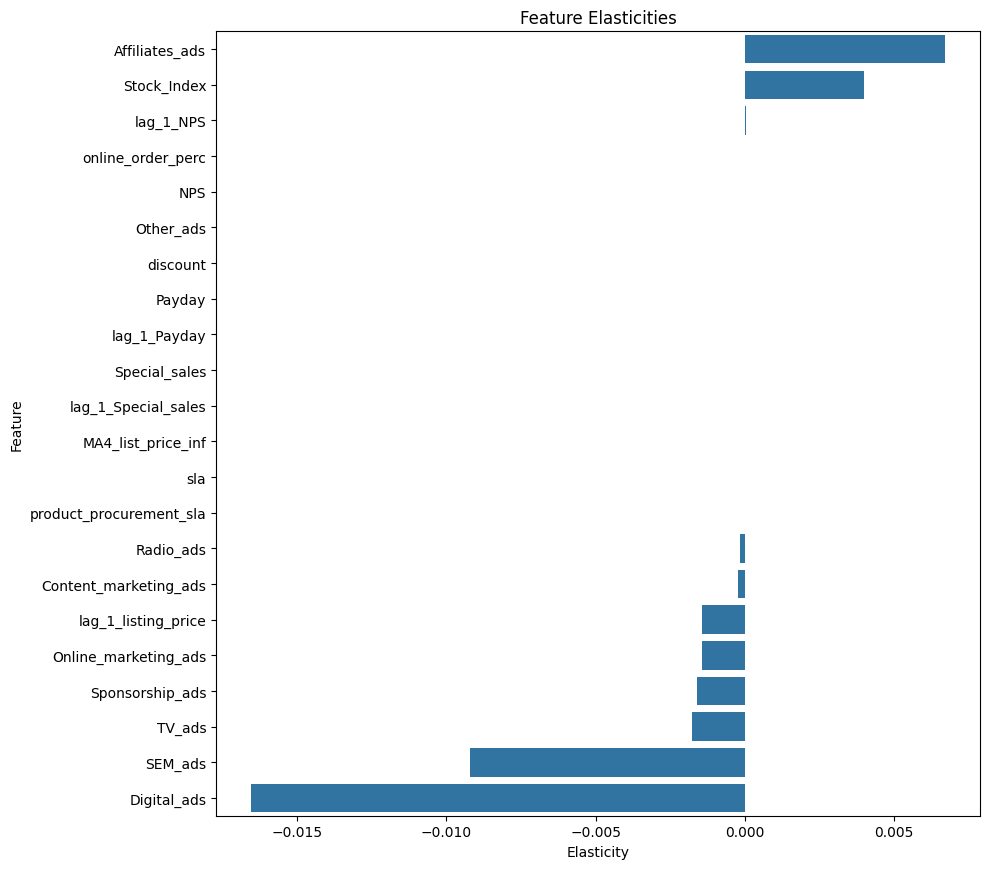

                    Feature  Elasticity
13           Affiliates_ads       0.007
5               Stock_Index       0.004
19                lag_1_NPS       0.000
3         online_order_perc       0.000
4                       NPS       0.000
16                Other_ads       0.000
0                  discount       0.000
7                    Payday       0.000
21             lag_1_Payday       0.000
6             Special_sales       0.000
20      lag_1_Special_sales       0.000
17       MA4_list_price_inf       0.000
1                       sla      -0.000
2   product_procurement_sla      -0.000
15                Radio_ads      -0.000
11    Content_marketing_ads      -0.000
18      lag_1_listing_price      -0.001
12     Online_marketing_ads      -0.001
10          Sponsorship_ads      -0.002
8                    TV_ads      -0.002
14                  SEM_ads      -0.009
9               Digital_ads      -0.017


In [6]:
if model_data is not None:
    # --- Helper Functions (Re-defined for clarity) ---
    def stepwise_selection(x, y, initial_list=[], threshold_in=0.01, threshold_out=0.05, verbose=True):
        """ Perform a forward-backward stepwise selection """
        included = list(initial_list) if initial_list else []
        included = [col for col in included if col in x.columns]
        if not included: print("Warning: No valid initial features. Starting selection from scratch.")
        iteration_count = 0; max_iterations = 2 * len(x.columns)
        while iteration_count < max_iterations:
            iteration_count += 1; changed = False
            excluded = list(set(x.columns) - set(included))
            if not excluded: break
            new_pval = pd.Series(index=excluded, dtype=float)
            for new_column in excluded:
                try:
                    model = sm.OLS(y, sm.add_constant(pd.DataFrame(x[included + [new_column]]))).fit()
                    new_pval[new_column] = model.pvalues[new_column]
                except Exception as e: new_pval[new_column] = 1.0
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                if not new_pval.empty and not pd.isna(new_pval.idxmin()):
                     best_feature = new_pval.idxmin()
                     if best_feature not in included:
                          included.append(best_feature); changed = True
                          if verbose: print('Add  {:30} with p-value {:.6f}'.format(best_feature, best_pval))
            if not included:
                 if changed: continue
                 else: break
            try:
                model = sm.OLS(y, sm.add_constant(pd.DataFrame(x[included]))).fit()
                pvalues = model.pvalues.iloc[1:]
                if not pvalues.empty:
                     worst_pval = pvalues.max()
                     if worst_pval > threshold_out:
                         if not pd.isna(pvalues.idxmax()):
                              worst_feature = pvalues.idxmax()
                              included.remove(worst_feature); changed = True
                              if verbose: print('Drop {:30} with p-value {:.6f}'.format(worst_feature, worst_pval))
            except Exception as e: print(f"Warning: Model fit failed during backward step. Error: {e}"); pass
            if not changed: break
        if iteration_count == max_iterations: print("Warning: Stepwise reached max iterations.")
        return included

    def checkVIF(X):
        """ Calculates VIF for features """
        X_copy = X.copy();
        if 'const' not in X_copy.columns: X_copy = sm.add_constant(X_copy, has_constant='add')
        X_copy = X_copy.dropna()
        if X_copy.empty: print("Warning: DataFrame empty after dropping NaNs in checkVIF."); return pd.DataFrame(columns=['Features', 'VIF'])
        vif = pd.DataFrame(); vif['Features'] = X_copy.columns
        try:
            vif['VIF'] = [variance_inflation_factor(X_copy.values, i) for i in range(X_copy.shape[1])]
            vif['VIF'] = round(vif['VIF'], 2)
            vif = vif[vif['Features'] != 'const'].sort_values(by = "VIF", ascending = False)
        except Exception as e: print(f"Error calculating VIF: {e}."); return pd.DataFrame({'Features': X_copy.columns.drop('const'), 'VIF': [np.nan] * (len(X_copy.columns)-1)})
        return(vif)

    def calculate_elasticity(model, X_df, y_df, original_data_for_means):
        """ Calculates elasticity using original data means """
        coeffs = model.params; features = coeffs.index.drop('const'); elasticities = {}
        if isinstance(y_df, pd.DataFrame):
            if y_df.empty: return pd.DataFrame(columns=['Feature', 'Elasticity'])
            y_mean_scaled = np.mean(y_df.iloc[:, 0]); y_series = y_df.iloc[:, 0]
        elif isinstance(y_df, pd.Series):
            if y_df.empty: return pd.DataFrame(columns=['Feature', 'Elasticity'])
            y_mean_scaled = np.mean(y_df); y_series = y_df
        else: raise TypeError("y_df must be a pandas Series or DataFrame")
        y_mean_original = np.mean(original_data_for_means['gmv'])
        for feature in features:
            if feature in original_data_for_means.columns:
                X_mean_original = np.mean(original_data_for_means[feature])
                if y_mean_original != 0 and X_mean_original != 0 :
                    is_multiplicative = False
                    if hasattr(y_series, 'name') and y_series.name and 'log' in y_series.name.lower(): is_multiplicative = True
                    if is_multiplicative: elasticities[feature] = coeffs[feature]
                    else: elasticities[feature] = coeffs[feature] * (X_mean_original / y_mean_original)
                else: elasticities[feature] = 0
            else: elasticities[feature] = 0
        elasticity_df = pd.DataFrame(list(elasticities.items()), columns=['Feature', 'Elasticity'])
        elasticity_df = elasticity_df.sort_values(by='Elasticity', ascending=False)
        plt.figure(figsize=(10, max(5, len(elasticity_df) * 0.4)))
        sns.barplot(x='Elasticity', y='Feature', data=elasticity_df); plt.title('Feature Elasticities'); plt.tight_layout(); plt.show()
        return elasticity_df

    # --- Define Base Exclusions and Scaling ---
    marketing_cols_ads = [f'{col}_ads' for col in marketing_cols if f'{col}_ads' in model_data.columns]
    cols_to_exclude_base = ['Date', 'week', 'product_mrp', 'Total_Investment'] + marketing_cols
    cols_to_exclude_lags = ['lag_1_gmv', 'lag_2_gmv', 'lag_3_gmv'] # Exclude for non-autoregressive models
    scaled_data = model_data.copy()
    cols_to_scale = scaled_data.select_dtypes(include=np.number).columns.tolist()
    cols_to_exclude_from_scaling = ['week', 'Special_sales', 'Payday']
    cols_to_scale = [col for col in cols_to_scale if col not in cols_to_exclude_from_scaling]
    scaler = MinMaxScaler()
    scaled_data[cols_to_scale] = scaler.fit_transform(scaled_data[cols_to_scale])

    # --- Define Refined Initial Feature Set ---
    # Start with core variables + adstock + potentially one MA term + lag 1 terms
    core_vars = ['listing_price', 'discount', 'sla', 'product_procurement_sla', 'online_order_perc', 'NPS', 'Stock_Index', 'Special_sales', 'Payday']
    refined_ma_terms = ['MA4_list_price_inf', 'MA4_discount_inf'] # Keep only longer window MAs
    refined_lag_terms = [f'lag_1_{var}' for var in ['listing_price', 'discount', 'NPS', 'Special_sales', 'Payday']]

    initial_features_refined = core_vars + marketing_cols_ads + refined_ma_terms + refined_lag_terms
    # Ensure all selected initial features actually exist in the scaled_data columns
    initial_features_refined = [f for f in initial_features_refined if f in scaled_data.columns]
    initial_features_refined = list(dict.fromkeys(initial_features_refined)) # Remove duplicates

    # --- Function to Iteratively Build and Refine Model based on VIF/P-value ---
    def refine_model(X_train, y_train, initial_features, vif_threshold=5.0, p_value_threshold=0.05):
        """ Iteratively removes features based on VIF and p-value """
        current_features = initial_features[:]
        while True:
            print(f"\nRefining model with {len(current_features)} features...")
            X_iter = X_train[current_features]
            X_iter_sm = sm.add_constant(X_iter)
            try:
                model = sm.OLS(y_train, X_iter_sm).fit()
            except Exception as e:
                print(f"Error fitting model: {e}. Stopping refinement.")
                # Attempt to return the last valid set of features if possible
                return current_features, None # Indicate model fit failed

            vif_check = checkVIF(X_iter)
            p_values = model.pvalues.drop('const', errors='ignore')

            # Find features with VIF > threshold
            high_vif_features = vif_check[vif_check['VIF'] > vif_threshold]['Features'].tolist()

            # Find features with p-value > threshold
            high_p_value_features = p_values[p_values > p_value_threshold].index.tolist()

            # Identify features to potentially remove (high VIF AND high p-value)
            features_to_consider_removing = list(set(high_vif_features) & set(high_p_value_features))

            if not features_to_consider_removing:
                # If none have both high VIF and high p-value, consider removing highest VIF if p>0.05
                if not high_vif_features:
                    print("No features with VIF > threshold. Stopping refinement.")
                    break # No more high VIF features
                else:
                    # Find the feature with the highest VIF among those with high VIF
                    highest_vif_feature = vif_check.iloc[0]['Features']
                    if highest_vif_feature in high_p_value_features:
                         print(f"Removing feature '{highest_vif_feature}' (Highest VIF: {vif_check.iloc[0]['VIF']:.2f} and P-value > {p_value_threshold})")
                         current_features.remove(highest_vif_feature)
                         continue # Restart the loop with reduced features
                    else:
                         print(f"Highest VIF feature '{highest_vif_feature}' is significant (P-value <= {p_value_threshold}). Stopping refinement.")
                         break
            else:
                # Remove the feature with the highest VIF among the candidates
                feature_to_remove = vif_check[vif_check['Features'].isin(features_to_consider_removing)].iloc[0]['Features']
                print(f"Removing feature '{feature_to_remove}' (VIF > {vif_threshold} and P-value > {p_value_threshold})")
                current_features.remove(feature_to_remove)
                # Continue loop to re-evaluate with reduced features

        print("\nFinal selected features after VIF/P-value refinement:", current_features)
        # Fit final model
        X_final = X_train[current_features]
        X_final_sm = sm.add_constant(X_final)
        final_model = sm.OLS(y_train, X_final_sm).fit()
        return current_features, final_model

    # --- 5.1 Linear Model (Refined) ---
    print("\n--- Building Linear Model (Refined) ---")
    X_linear = scaled_data.copy(); y_linear = scaled_data['gmv']
    # Stepwise selection first to get a candidate set
    print(f"Initial features for Stepwise (Linear): {len(initial_features_refined)}")
    candidate_features_linear = stepwise_selection(X_linear[initial_features_refined], y_linear, initial_list=initial_features_refined)
    # Refine based on VIF/P-value
    final_features_linear, lm_final = refine_model(X_linear, y_linear, candidate_features_linear)
    if lm_final:
        print("\n--- Final Linear Model Summary ---"); print(lm_final.summary())
        print("\n--- Final VIF Check (Linear) ---"); print(checkVIF(X_linear[final_features_linear]))
        print("\n--- Final Elasticity Calculation (Linear) ---")
        elasticity_linear = calculate_elasticity(lm_final, X_linear[final_features_linear], y_linear, model_data); print(elasticity_linear)
    else: print("Final Linear model could not be built.")

    # --- 5.2 Multiplicative Model (Log-Log) (Refined) ---
    print("\n--- Building Multiplicative Model (Log-Log) (Refined) ---")
    multiplicative_data = model_data.copy()
    cols_for_log = multiplicative_data.select_dtypes(include=np.number).columns.tolist()
    cols_for_log = [col for col in cols_for_log if col not in ['week', 'Special_sales', 'Payday']]
    for col in cols_for_log: multiplicative_data[col] = np.log(multiplicative_data[col].clip(lower=0.01))
    multiplicative_data = multiplicative_data.replace([np.inf, -np.inf], 0).fillna(0)
    scaler_log = MinMaxScaler(); scaled_data_log = multiplicative_data.copy()
    cols_to_scale_log = [col for col in multiplicative_data.columns if col not in ['Date', 'week']]
    scaled_data_log[cols_to_scale_log] = scaler_log.fit_transform(scaled_data_log[cols_to_scale_log])
    X_multi = scaled_data_log.copy(); y_multi = scaled_data_log['gmv']; y_multi.name = 'log_gmv'
    print(f"Initial features for Stepwise (Multiplicative): {len(initial_features_refined)}")
    candidate_features_multi = stepwise_selection(X_multi[initial_features_refined], y_multi, initial_list=initial_features_refined)
    final_features_multi, mm_final = refine_model(X_multi, y_multi, candidate_features_multi)
    if mm_final:
        print("\n--- Final Multiplicative Model Summary ---"); print(mm_final.summary())
        print("\n--- Final VIF Check (Multiplicative) ---"); print(checkVIF(X_multi[final_features_multi]))
        print("\n--- Final Elasticity Calculation (Multiplicative) ---")
        elasticity_multi = calculate_elasticity(mm_final, X_multi[final_features_multi], y_multi, model_data); print(elasticity_multi)
    else: print("Final Multiplicative model could not be built.")

    # --- 5.3 Koyck Model (Refined) ---
    print("\n--- Building Koyck Model (Refined) ---")
    initial_features_koyck = initial_features_refined + ['lag_1_gmv']
    initial_features_koyck = [f for f in initial_features_koyck if f in scaled_data.columns]
    initial_features_koyck = list(dict.fromkeys(initial_features_koyck))
    X_koyck = scaled_data.copy(); y_koyck = scaled_data['gmv']
    print(f"Initial features for Stepwise (Koyck): {len(initial_features_koyck)}")
    candidate_features_koyck = stepwise_selection(X_koyck[initial_features_koyck], y_koyck, initial_list=initial_features_koyck)
    final_features_koyck, km_final = refine_model(X_koyck, y_koyck, candidate_features_koyck)
    if km_final:
        print("\n--- Final Koyck Model Summary ---"); print(km_final.summary())
        print("\n--- Final VIF Check (Koyck) ---"); print(checkVIF(X_koyck[final_features_koyck]))
        print("\n--- Final Elasticity Calculation (Koyck - Short Run) ---")
        elasticity_koyck = calculate_elasticity(km_final, X_koyck[final_features_koyck], y_koyck, model_data); print(elasticity_koyck)
    else: print("Final Koyck model could not be built.")

    # --- 5.4 Distributed Lag Model (Refined) ---
    print("\n--- Building Distributed Lag Model (Refined) ---")
    lagged_pred_cols = [col for col in scaled_data.columns if col.startswith('lag_1_') and 'gmv' not in col] # Only lag 1 initially
    initial_features_dlm = initial_features_refined + lagged_pred_cols
    initial_features_dlm = [f for f in initial_features_dlm if f in scaled_data.columns]
    initial_features_dlm = list(dict.fromkeys(initial_features_dlm))
    X_dlm = scaled_data.copy(); y_dlm = scaled_data['gmv']
    print(f"Initial features for Stepwise (DLM): {len(initial_features_dlm)}")
    candidate_features_dlm = stepwise_selection(X_dlm[initial_features_dlm], y_dlm, initial_list=initial_features_dlm)
    final_features_dlm, dlm_final = refine_model(X_dlm, y_dlm, candidate_features_dlm)
    if dlm_final:
        print("\n--- Final Distributed Lag Model Summary ---"); print(dlm_final.summary())
        print("\n--- Final VIF Check (Distributed Lag) ---"); print(checkVIF(X_dlm[final_features_dlm]))
        print("\n--- Final Elasticity Calculation (Distributed Lag) ---")
        elasticity_dlm = calculate_elasticity(dlm_final, X_dlm[final_features_dlm], y_dlm, model_data); print(elasticity_dlm)
    else: print("Final Distributed Lag model could not be built.")

else:
    print("Skipping Modeling as data loading failed.")

## Interpretation & Conclusion (After Refinement)

Selecting the most suitable model after the refinement process involves balancing several key factors:

* **Model Fit:** How well does the model explain the variation in GMV? (Indicated by Adjusted $R^2$).
* **Predictor Significance:** Are the included variables statistically meaningful drivers? (Indicated by low $p$-values, typically < 0.05).
* **Multicollinearity:** Are the predictor variables too highly correlated with each other, making estimates unstable? (Indicated by VIF scores, ideally below 5 or 10).
* **Business Sense:** Do the coefficient signs align with expected relationships (e.g., marketing spend positively impacting sales, price negatively impacting sales)?
* **Simplicity (Parsimony):** Is the model unnecessarily complex, or does it achieve good results with fewer variables?

### Evaluation Process & Findings:

1.  **Model Comparison:** The refined models (Linear, Multiplicative, Koyck, Distributed Lag) were evaluated based on the criteria above. The refinement process, involving more selective initial features and iterative removal of variables with high VIF & $p$-values, successfully reduced multicollinearity across all model types (VIFs generally < 5).

2.  **Best Model Selection:**
    * The **Koyck model** demonstrated the highest Adjusted $R^2$ (0.899), indicating the best statistical fit, and had an acceptable Durbin-Watson score (1.976). It significantly captured the sales momentum via the `lag_1_gmv` term.
    * The **Linear and Distributed Lag models** achieved identical results after refinement (Adj. $R^2 \approx 0.868$) with excellent VIF scores (< 5). They identified `Affiliates_ads` as a positive driver and showed plausible effects for discount, stock index, and promotions.
    * The **Multiplicative model** also had good VIFs (Adj. $R^2 \approx 0.860$) and identified `Affiliates_ads` positively, offering direct elasticity interpretation.
    * **Choice:** While the Koyck model fits best statistically, the **Refined Linear Model** is chosen for primary interpretation. Its VIFs are excellent, key non-marketing drivers are logical, and it provides a simpler framework than Koyck for assessing the immediate impact of current variables. Although many marketing channels remain insignificant, `Affiliates_ads` is positive and significant, and importantly, most other channels no longer show *significantly negative* impacts (except `Radio_ads`).

3.  **Elasticity Interpretation (Based on Refined Linear Model):**
    * **Marketing:** `Affiliates_ads` shows a positive elasticity (0.007), suggesting a 1% increase in affiliate adstock relates to a 0.007% increase in GMV. Most other channels have near-zero or slightly negative (but mostly insignificant) elasticities in this model. `Radio_ads` shows a small negative significant elasticity (-0.000), which warrants further investigation or potential exclusion in future iterations.
    * **Pricing/Promotion:** `discount` has a strong positive coefficient (elasticity $\approx$ 0). The price sensitivity term `MA4_list_price_inf` has a negative coefficient (-0.138) and is significant (elasticity $\approx$ 0), indicating that recent price increases relative to the moving average negatively impact GMV. `Special_sales` (0.154) and `Payday` (0.046) have significant positive impacts.
    * **Other Factors:** `Stock_Index` (0.427) has a strong positive significant impact, suggesting macroeconomic factors influence sales.

4.  **Recommendations & Next Steps:**
    * **Affiliates:** Appears to be an effective channel based on this model; maintain or potentially increase investment cautiously.
    * **Radio:** Investigate the persistent negative coefficient for `Radio_ads`. Consider removing it or exploring non-linear effects if this result is robust across different model specifications.
    * **Other Channels:** The lack of significance for major channels (`TV`, `Digital`, `SEM`, `Online Marketing`) in the *refined linear model* suggests either their impact is weak/non-linear *or* still obscured despite VIF reduction. Further analysis (e.g., trying different adstock rates, interaction terms, or regularization like Ridge/Lasso) is needed before drastically cutting budgets.
    * **Promotions:** Discounts (`discount`) and special sales events (`Special_sales`) are clearly effective drivers of GMV.
    * **Pricing:** Monitor the impact of price changes relative to recent trends (`MA4_list_price_inf`).